# Task 1 — Environment, Data Acquisition, and Exploratory Analysis

**Objective:** Load the dataset, audit it, build EDA figures, and save `data/cleaned.csv`.

**Inputs:** `data/raw/winequality-white.csv`

**Outputs:** `data/cleaned.csv`, EDA exports in `reports/`.

## Dataset statement
- Dataset: Wine Quality (white wine subset)
- Source: UCI Machine Learning Repository
- DOI: 10.24432/C56S3T
- License: CC BY 4.0

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
REPORTS_DIR = PROJECT_ROOT / 'reports'
MODELS_DIR = PROJECT_ROOT / 'models'
RANDOM_STATE = 42
EPS = 1e-6
def savefig(filename):
    plt.tight_layout(); plt.savefig(REPORTS_DIR / filename, dpi=300, bbox_inches='tight'); plt.show()

In [2]:
feature_descriptions = {
    'fixed acidity':'Most acids involved with wine or fixed in the finished product.',
    'volatile acidity':'Acetic acid in wine; too much can lead to an unpleasant vinegar taste.',
    'citric acid':'Adds freshness and flavor to wines in small quantities.',
    'residual sugar':'Amount of sugar remaining after fermentation stops.',
    'chlorides':'Amount of salt in the wine.',
    'free sulfur dioxide':'Free form of SO2 that prevents microbial growth and oxidation.',
    'total sulfur dioxide':'Total amount of free and bound forms of SO2.',
    'density':'Density of the wine, influenced by alcohol and sugar content.',
    'pH':'Describes how acidic or basic the wine is.',
    'sulphates':'Additive that can contribute to sulfur dioxide gas and preservation.',
    'alcohol':'Alcohol percentage by volume.',
    'quality':'Sensory quality score ranging from 0 to 10.'
}

In [3]:
df_raw = pd.read_csv(RAW_DIR / 'winequality-white.csv', sep=';')
structure_df = pd.DataFrame({'column': df_raw.columns, 'dtype': [str(d) for d in df_raw.dtypes], 'non_null_count': df_raw.notna().sum().values, 'description': [feature_descriptions.get(c, '') for c in df_raw.columns]})
display(structure_df)
audit=[]
for col in df_raw.columns:
    s=df_raw[col]; q1=s.quantile(0.25); q3=s.quantile(0.75); iqr=q3-q1
    audit.append({'column':col,'missing_values':int(s.isna().sum()),'dataset_duplicate_rows':int(df_raw.duplicated().sum()),'iqr_outlier_count':int(((s<(q1-1.5*iqr))|(s>(q3+1.5*iqr))).sum())})
display(pd.DataFrame(audit))

,column,dtype,non_null_count,description
0,fixed acidity,float64,4898,Most acids involved with wine or fixed in the ...
1,volatile acidity,float64,4898,Acetic acid in wine; too much can lead to an u...
2,citric acid,float64,4898,Adds freshness and flavor to wines in small qu...
3,residual sugar,float64,4898,Amount of sugar remaining after fermentation s...
4,chlorides,float64,4898,Amount of salt in the wine.
5,free sulfur dioxide,float64,4898,Free form of SO2 that prevents microbial growt...
6,total sulfur dioxide,float64,4898,Total amount of free and bound forms of SO2.
7,density,float64,4898,"Density of the wine, influenced by alcohol and..."
8,pH,float64,4898,Describes how acidic or basic the wine is.
9,sulphates,float64,4898,Additive that can contribute to sulfur dioxide...


,column,missing_values,dataset_duplicate_rows,iqr_outlier_count
0,fixed acidity,0,937,119
1,volatile acidity,0,937,186
2,citric acid,0,937,270
3,residual sugar,0,937,7
4,chlorides,0,937,208
5,free sulfur dioxide,0,937,50
6,total sulfur dioxide,0,937,19
7,density,0,937,5
8,pH,0,937,75
9,sulphates,0,937,124


## Cleaning decisions
- No missing values were found.
- Exact duplicate rows are removed.
- IQR outliers are documented but not automatically removed.

In [4]:
df = df_raw.drop_duplicates().reset_index(drop=True)
df.to_csv(DATA_DIR / 'cleaned.csv', index=False)

## Visualisation 1 — quality distribution

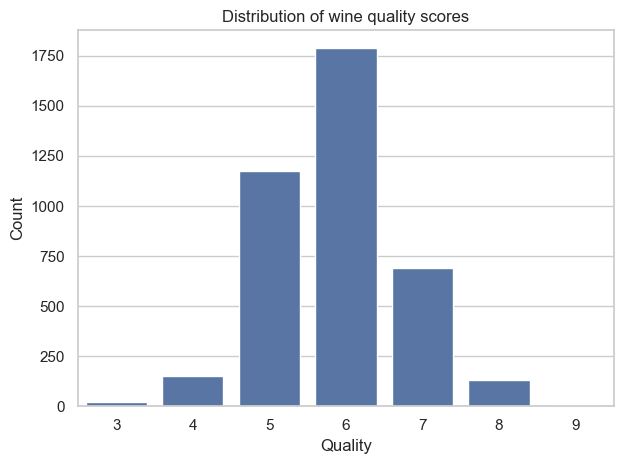

In [5]:
plt.figure(); sns.countplot(data=df, x='quality', color='#4C72B0'); plt.title('Distribution of wine quality scores'); plt.xlabel('Quality'); plt.ylabel('Count'); savefig('eda_quality_distribution.png')

## Visualisation 2 — correlation heatmap

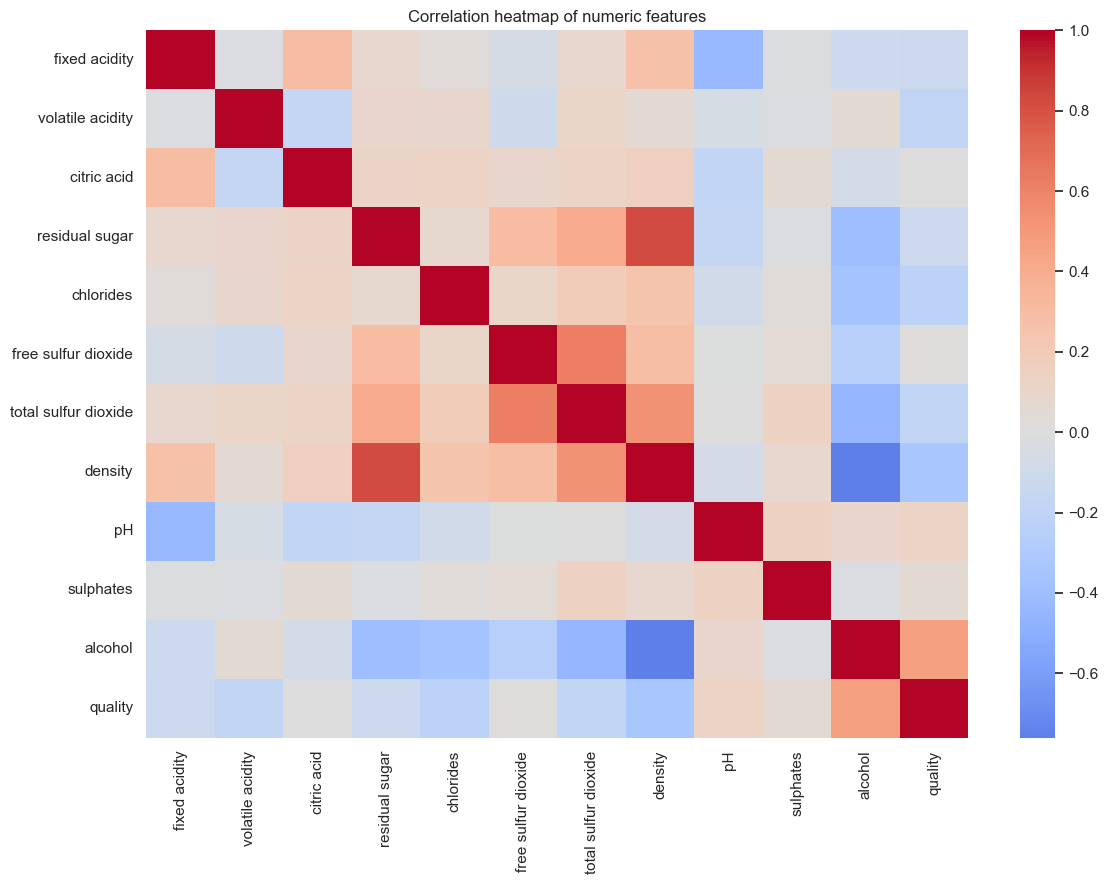

In [6]:
plt.figure(figsize=(12,9)); sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0, annot=False); plt.title('Correlation heatmap of numeric features'); savefig('eda_correlation_heatmap.png')

## Visualisation 3 — alcohol vs quality

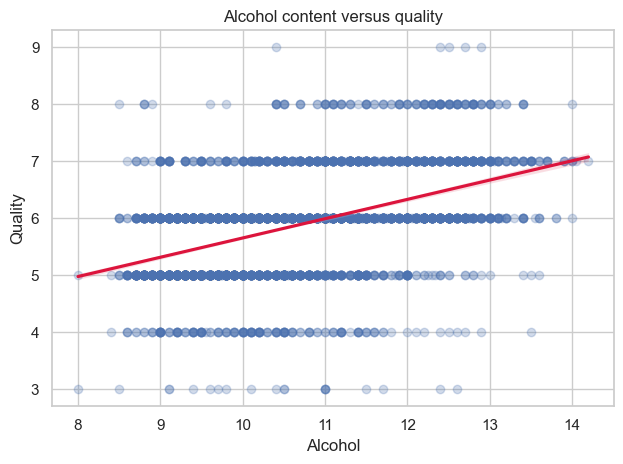

In [7]:
plt.figure(); sns.regplot(data=df, x='alcohol', y='quality', scatter_kws={'alpha':0.25}, line_kws={'color':'crimson'}); plt.title('Alcohol content versus quality'); plt.xlabel('Alcohol'); plt.ylabel('Quality'); savefig('eda_alcohol_vs_quality.png')

## Visualisation 4 — volatile acidity by quality

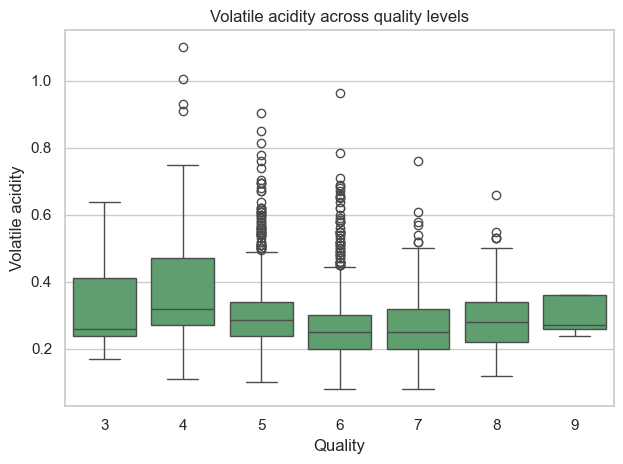

In [8]:
plt.figure(); sns.boxplot(data=df, x='quality', y='volatile acidity', color='#55A868'); plt.title('Volatile acidity across quality levels'); plt.xlabel('Quality'); plt.ylabel('Volatile acidity'); savefig('eda_volatile_acidity_boxplot.png')

## Visualisation 5 — residual sugar vs density

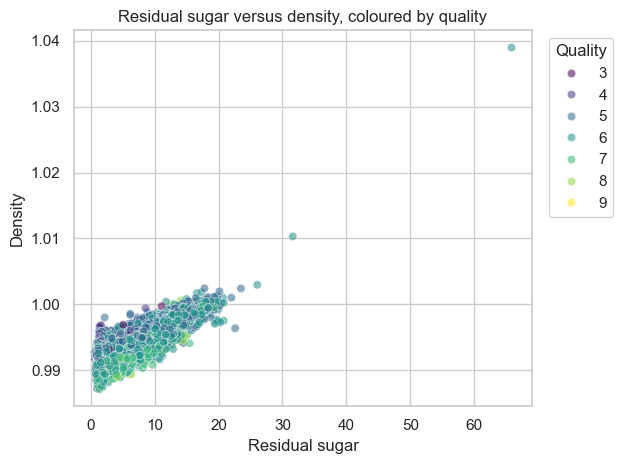

In [9]:
plt.figure(); sns.scatterplot(data=df, x='residual sugar', y='density', hue='quality', palette='viridis', alpha=0.55); plt.title('Residual sugar versus density, coloured by quality'); plt.xlabel('Residual sugar'); plt.ylabel('Density'); plt.legend(title='Quality', bbox_to_anchor=(1.02,1), loc='upper left'); savefig('eda_residual_sugar_density_scatter.png')

## Student summary
In this Exploratory Data Analysis, we investigated the physicochemical properties of the white wine dataset to identify features predictive of wine quality. The quality scores are heavily imbalanced, primarily centered around levels 5, 6, and 7. Correlation analysis revealed that alcohol content is the strongest positive indicator of quality, while density and volatile acidity exhibit significant negative correlations. Moreover, the scatter plot of residual sugar versus density showed a clear positive distribution, indicating sweeter wines are generally denser. These insights tell us that models should strongly rely on alcohol and density. Given the lack of linear separation and the presence of feature interactions, non-linear regressors are likely to perform better than simple linear models. The dataset is now clean and ready for modeling.